In [2]:
from src.utils import get_data_env
from src.UPDATED_dataloading import EpiConfig, DataOrchestrator
from src.UPDATED_models import PersistenceModel, NodeRFModel, NodeLSTMModel
from src.UPDATED_dataloading import GraphDataLoaderManager, ShallowDataLoaderManager

from src.UPDATED_models import GATv2Model

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 2
horizon_leadtime= 3
sequence_length = 1
lags            = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

dataorchestrator    = (DataOrchestrator(config).build())

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.75, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()

In [4]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

PersistenceModel(name='Persistence Model')


==               Node LSTM model                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7055, val loss: 1.1067 ✓ (new best)
Epoch 2 train loss: 0.6785, val loss: 1.0813 ✓ (new best)
Epoch 3 train loss: 0.6737, val loss: 1.0267 ✓ (new best)
Epoch 4 train loss: 0.6653, val loss: 0.9850 ✓ (new best)
Epoch 5 train loss: 0.6559, val loss: 0.9255 ✓ (new best)
Epoch 6 train loss: 0.6499, val loss: 0.8749 ✓ (new best)
Epoch 7 train loss: 0.6403, val loss: 0.8321 ✓ (new best)
Epoch 8 train loss: 0.6376, val loss: 0.8180 ✓ (new best)
Epoch 9 train loss: 0.6264, val loss: 0.8038 ✓ (new best)
Epoch 10 train loss: 0.6215, val loss: 0.8024 ✓ (new best)
Epoch 11 train loss: 0.6098, val loss: 0.8000 ✓ (new best)
Epoch 12 train loss: 0.5974, val loss: 0.7896 ✓ (new best)
Epoch 13 train loss: 0.5848, val loss: 0.7741 ✓ (new best)
Epoch 14 train loss: 0.5751, val loss: 0.7609 ✓ (new best)
Epoch 15 train loss: 0.5670, val

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 402.75it/s]


Test loss: 0.8637


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

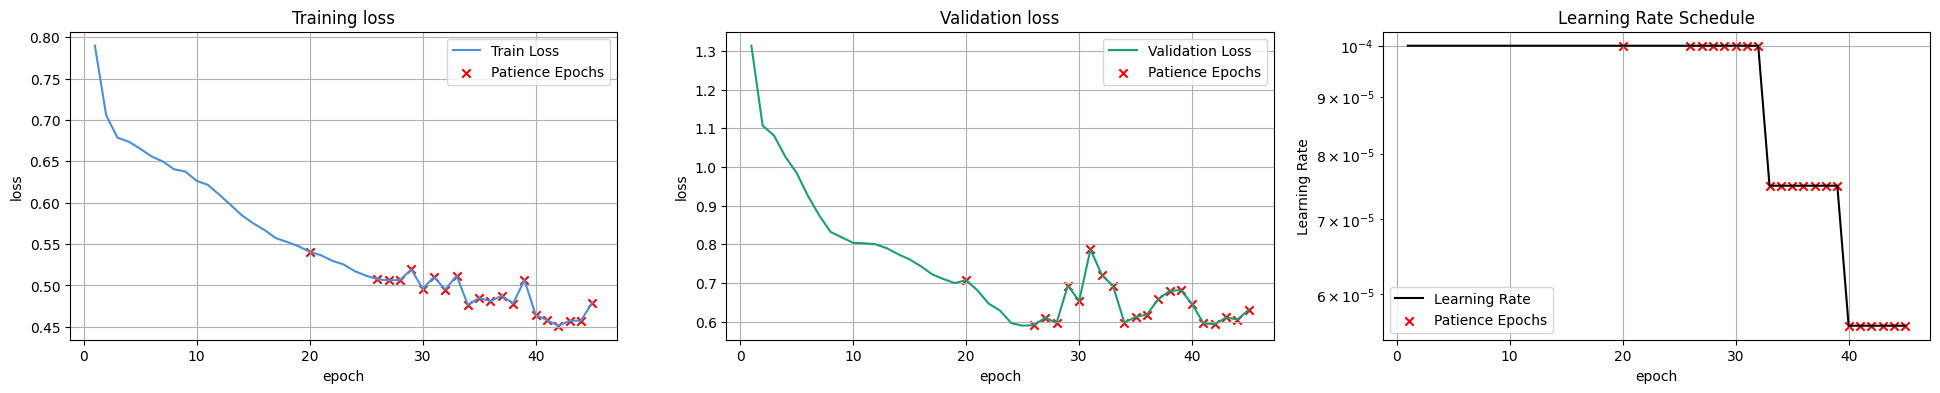

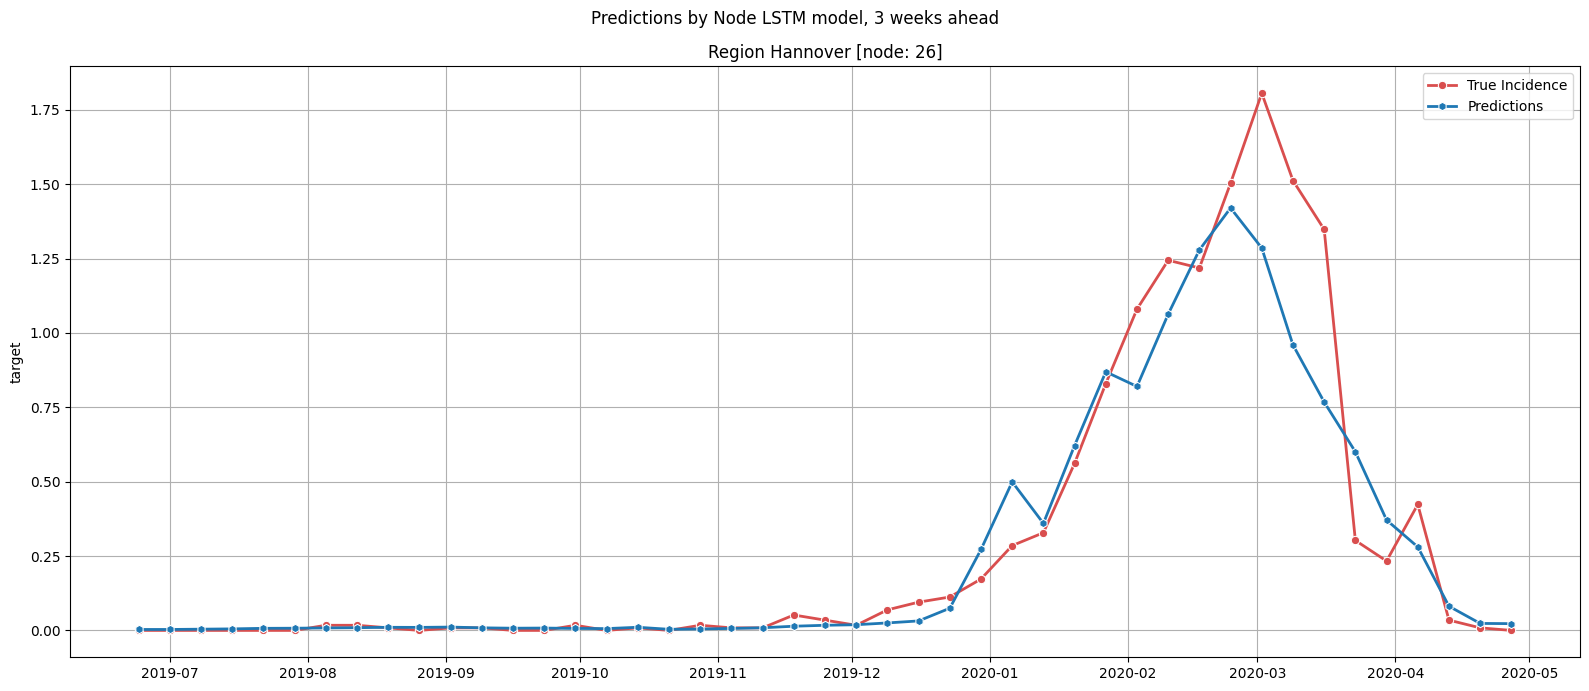

In [5]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'Node LSTM model')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)

In [6]:
from src.UPDATED_evaluation.evaluator import Evaluator

In [13]:
lstm.dataloadermanager.dataloader_collection

<GraphDataLoaderCollection(train, val, test, main)>

In [7]:
evaluation = Evaluator([lstm,  persistence])
evaluation.add_evaluation(0, 'test')
evaluation.add_evaluation(1, 'test')

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.05it/s]


/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


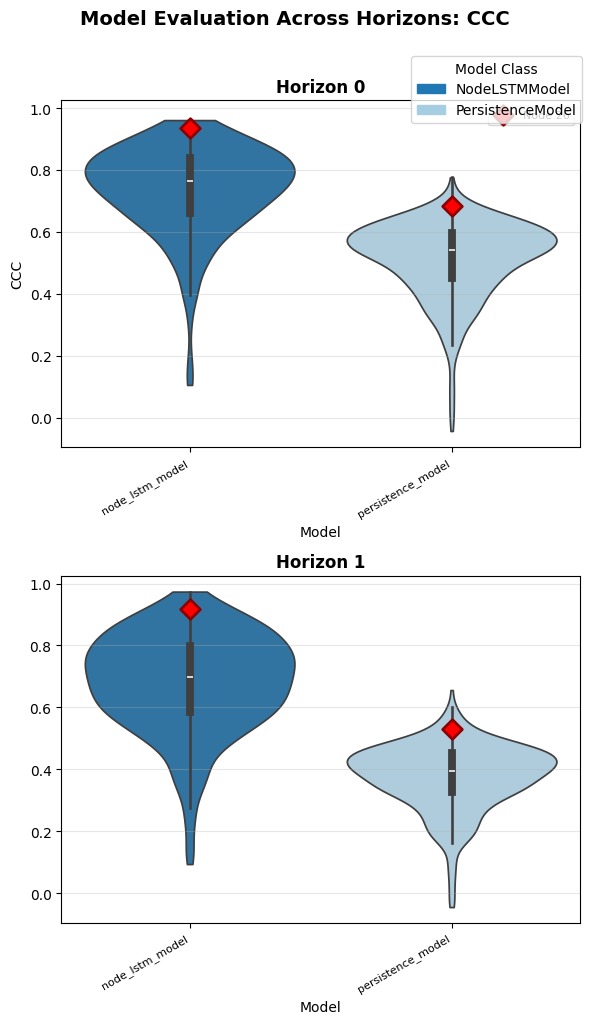

In [10]:
evaluation.plotter.plot_metric_horizons_separate('ccc', horizons = [0,1], plot_type='violin', highlight_node=26)